In [10]:
import os
import json


def load_aokvqa(aokvqa_dir, split, version='v1p0'):
    assert split in ['train', 'val', 'test', 'test_w_ans']
    dataset = json.load(open(
        os.path.join(aokvqa_dir, f"aokvqa_{version}_{split}.json")
    ))
    return dataset

def get_coco_path(split, image_id, coco_dir):
    return os.path.join(coco_dir, f"{split}2017", f"{image_id:012}.jpg")

jNCNiNaH5MCygmSSRWszph
../datasets_/coco/train2017/000000129247.jpg


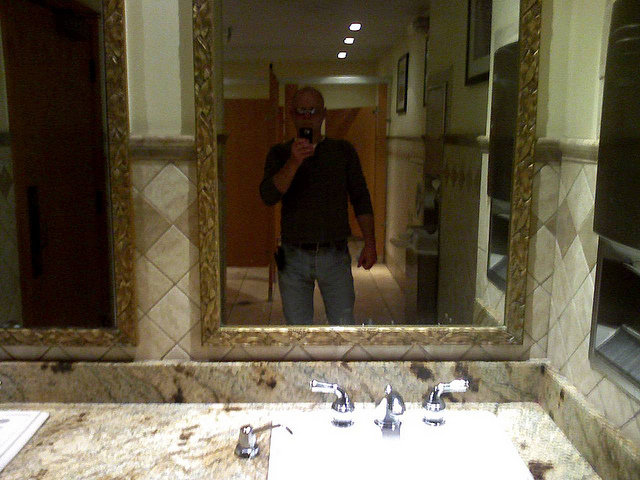

Where does the man carry his cell phone?
['shirt pocket', 'jeans pocket', 'messenger bag', 'side holster']
The man has a holder to carry his cell phone on his side.
--------------------------------------------------
oAiAYGHU4MQKzoRbtnzp3n
../datasets_/coco/train2017/000000105110.jpg


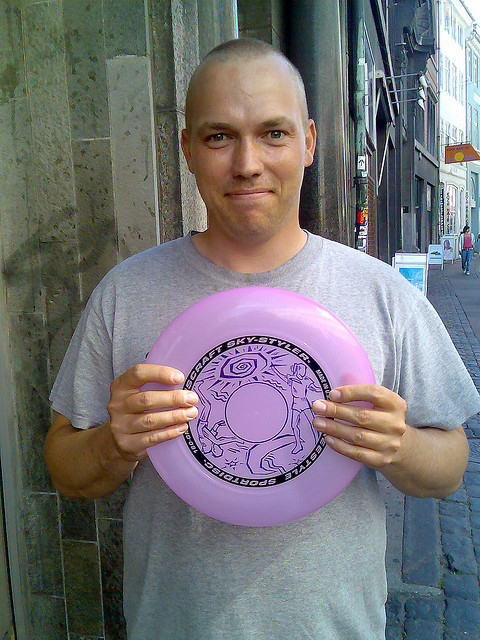

This frisbee is how many grams?
['200', '300', '160', '250']
Frisbees have a standard weight of 160 grams.
--------------------------------------------------
6V2gC67rKSZrYAQdh7bmte
../datasets_/coco/train2017/000000133456.jpg


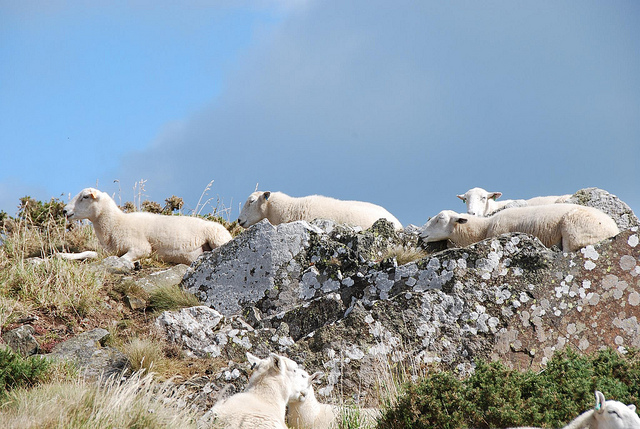

What are the animals doing on the hill?
['mating', 'eating', 'fighting', 'sitting']
The animals are lying down. they are not doing anything else.
--------------------------------------------------
VsTCHkhiXJTB2UEQJjjHb4
../datasets_/coco/train2017/000000208963.jpg


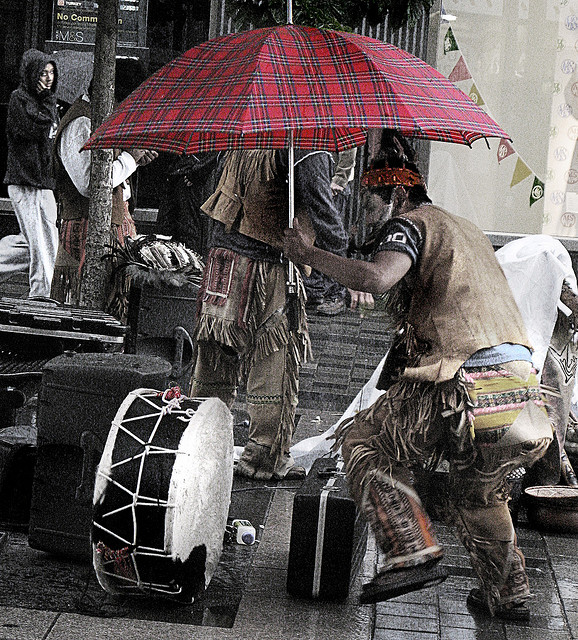

What is the white circle in front of the man?
['pan', 'clock', 'stool', 'drum']
It is a fabric material stretched over taut so it will produce a sound
--------------------------------------------------
jLDExkkdhHL35FHVEY9YRU
../datasets_/coco/train2017/000000335047.jpg


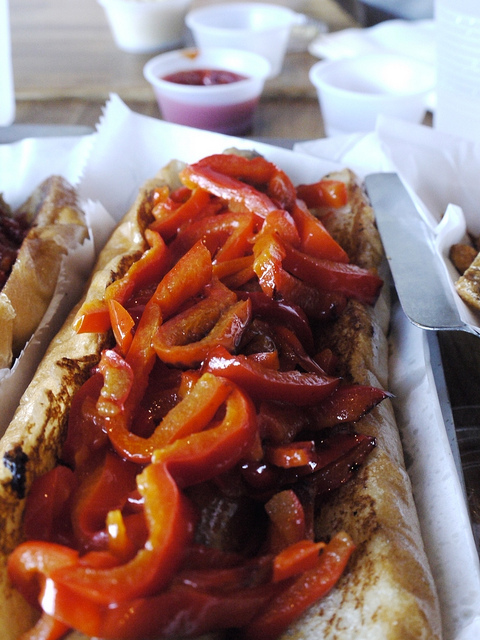

What is on top of the sandwich?
['tater tots', 'red peppers', 'mustard', 'eggs']
There are sliced vegetables on top of the sandwich.
--------------------------------------------------


In [15]:
import random
random.seed(0)


aokvqa_dir = '../datasets_/aokvqa'
train_dataset = load_aokvqa(aokvqa_dir, 'train')  # also 'val' or 'test'

for i in range(5):
    id = random.randint(0, len(train_dataset))

    dataset_example = train_dataset[id]
    print(dataset_example['question_id'])
    # 22MexNkBPpdZGX6sxbxVBH

    coco_dir = '../datasets_/coco'
    image_path = get_coco_path('train', dataset_example['image_id'], coco_dir)
    print(image_path)
    # vizuaalize the image
    from PIL import Image
    image = Image.open(image_path)
    image.show()
    # ./datasets/coco/train2017/000000299207.jpg

    print(dataset_example['question'])
    print(dataset_example['choices'])
    # What is the man by the bags awaiting?
    # ['skateboarder', 'train', 'delivery', 'cab']

    correct_choice = dataset_example['choices'][ dataset_example['correct_choice_idx'] ]
    # Corrrect: cab

    print(dataset_example['rationales'][0])
    print('-'*50)
    # A train would not be on the street, he would not have luggage waiting for a delivery, and the skateboarder is there and not paying attention to him so a cab is the only possible answer.